In [13]:
import numpy as np
import matplotlib.pyplot as plt
import argparse

# Ovulation Simulator 2000

Not dependend of first day of last period but first day of next period

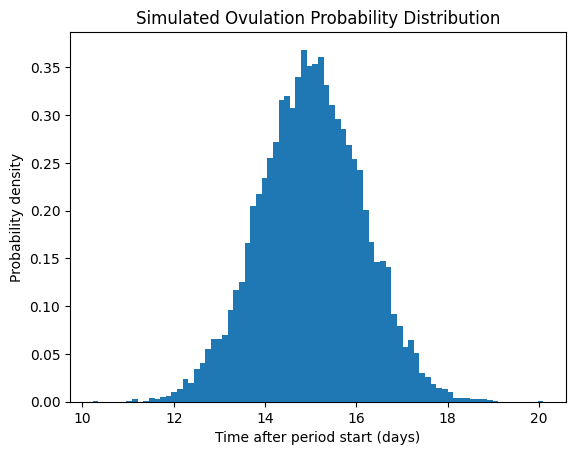

In [14]:
# ---- Time conversion ----
GRANULARITY_TO_DAYS = {
    "seconds": 1 / 86400,
    "minutes": 1 / 1440,
    "hours": 1 / 24,
    "days": 1
}

# ---- Ovulation simulation ----
def simulate_ovulation(
    typical_cycle_length=28,
    cycle_regularity=2,
    distribution="normal",
    samples=10000
):
    """
    Returns ovulation timing (days after period start)
    """

    # Luteal phase (more stable)
    luteal_mean = 13
    luteal_sd = 1

    luteal = np.random.normal(luteal_mean, luteal_sd, samples)

    # Cycle length variation
    if distribution == "normal":
        cycle_lengths = np.random.normal(typical_cycle_length, cycle_regularity, samples)

    elif distribution == "lognormal":
        sigma = cycle_regularity / typical_cycle_length
        cycle_lengths = np.random.lognormal(
            mean=np.log(typical_cycle_length),
            sigma=sigma,
            size=samples
        )

    elif distribution == "triangular":
        cycle_lengths = np.random.triangular(
            typical_cycle_length - 2 * cycle_regularity,
            typical_cycle_length,
            typical_cycle_length + 2 * cycle_regularity,
            samples
        )

    else:
        raise ValueError("Unsupported distribution")

    # Ovulation timing
    ovulation_day = cycle_lengths - luteal
    return ovulation_day


# ---- Main ----
def main(cycle_length=28, regularity=0.5, distribution="normal", samples=10000, granularity="days"):
    # parser = argparse.ArgumentParser()

    # parser.add_argument("--cycle_length", type=float, default=28)
    # parser.add_argument("--regularity", type=float, default=2)
    # parser.add_argument("--distribution", type=str, default="normal",
    #                     choices=["normal", "lognormal", "triangular"])
    # parser.add_argument("--granularity", type=str, default="days",
    #                     choices=["seconds", "minutes", "hours", "days"])
    # parser.add_argument("--samples", type=int, default=20000)

    # args = parser.parse_args()

    ovulation_days = simulate_ovulation(
        cycle_length,
        regularity,
        distribution,
        samples
    )

    # Convert to chosen granularity
    factor = 1 / GRANULARITY_TO_DAYS[granularity]
    ovulation_units = ovulation_days * factor

    plt.hist(ovulation_units, bins=80, density=True)
    plt.xlabel(f"Time after period start ({granularity})")
    plt.ylabel("Probability density")
    plt.title("Simulated Ovulation Probability Distribution")

    plt.show()


if __name__ == "__main__":
    main()